# **AI-Based Hiring Prediction System**

## **Project Objective**

The goal of this project is to develop a Machine Learning model that predicts whether a candidate will be **Hired** or **Rejected** based on resume information.

The dataset contains candidate details such as:

- Skills
- Experience
- Education
- Certifications
- Job Role
- Salary Expectation
- Projects Count

This project simulates a real-world AI resume screening system used by HR departments to automate the hiring process.

## **Step 1: Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

## **Step 2: Load the Dataset**

In [2]:
df = pd.read_csv("hiring.csv")

## **Step 3: Explore the Dataset**

In [3]:
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [4]:
df.tail()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
995,996,Brenda Williams,"Cybersecurity, Linux, Ethical Hacking",0,B.Sc,NaN,Cybersecurity Analyst,Reject,114364,9,60
996,997,Colleen Hicks,"Deep Learning, Machine Learning",0,MBA,Deep Learning Specialization,Data Scientist,Reject,103294,5,45
997,998,Michelle Molina,"TensorFlow, NLP",0,B.Tech,Google ML,AI Researcher,Hire,113855,9,65
998,999,Danielle Horn,"Linux, Networking, Cybersecurity, Ethical Hacking",8,PhD,AWS Certified,Cybersecurity Analyst,Hire,83146,10,100
999,1000,Chad Collins,"SQL, Machine Learning, Python, Deep Learning",7,M.Tech,Deep Learning Specialization,Data Scientist,Hire,119474,3,100


In [5]:
df.shape

(1000, 11)

In [6]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

## **Step 4: Understand the Dataset**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [8]:
df.describe(include='all')

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000,1000,1000.000000,1000,726,1000,1000,1000.000000,1000.00000,1000.000000
unique,NaN,989,238,NaN,5,3,4,2,NaN,NaN,NaN
top,NaN,Sarah Jones,"Python, Machine Learning",NaN,B.Sc,Deep Learning Specialization,AI Researcher,Hire,NaN,NaN,NaN
freq,NaN,3,11,NaN,205,255,257,812,NaN,NaN,NaN
mean,500.500000,NaN,NaN,4.896000,NaN,NaN,NaN,NaN,79994.486000,5.13300,83.950000
std,288.819436,NaN,NaN,3.112695,NaN,NaN,NaN,NaN,23048.472549,3.23137,20.983036
min,1.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,40085.000000,0.00000,15.000000
25%,250.750000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,60415.750000,2.00000,70.000000
50%,500.500000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,79834.500000,5.00000,100.000000
75%,750.250000,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,99583.250000,8.00000,100.000000


## **Step 5: Check Missing Values**

In [9]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [10]:
df.fillna("Unknown", inplace=True)

In [11]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,0
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


## **Step 6: Remove Duplicate Records**

In [12]:
df.duplicated().sum()

np.int64(0)

## **Step 7: Exploratory Data Analysis (EDA)**

### **Hiring Decision Distribution**

Visualize the number of hired and rejected candidates.

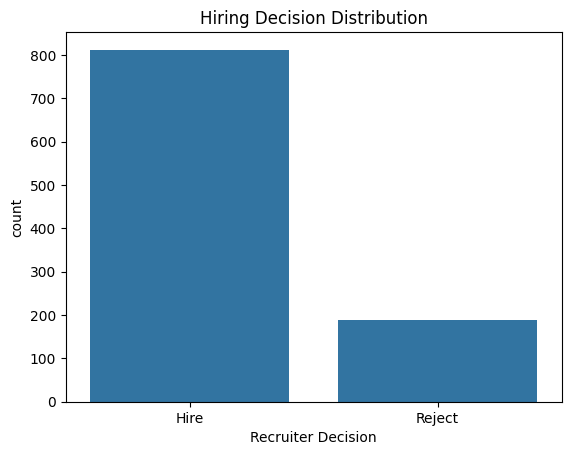

In [13]:
sns.countplot(x="Recruiter Decision", data=df)

plt.title("Hiring Decision Distribution")
plt.show()

### **Education Distribution**
Analyze the education qualifications of candidates.

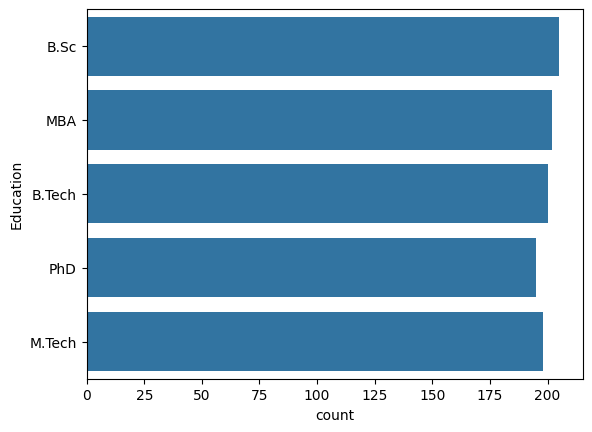

In [14]:
sns.countplot(y="Education", data=df)

plt.show()

### **Job Role Distribution**

Display the frequency of different job roles.

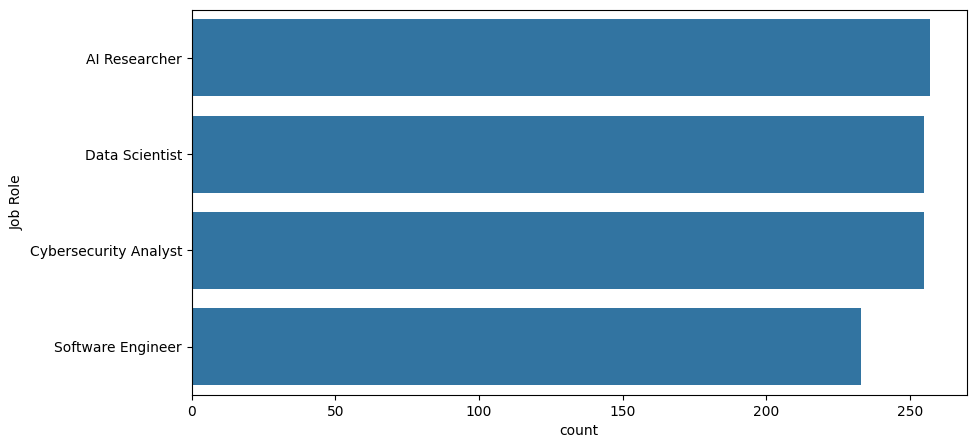

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(y="Job Role", data=df)

plt.show()

### **Experience Distribution**

Observe how candidate experience is distributed.

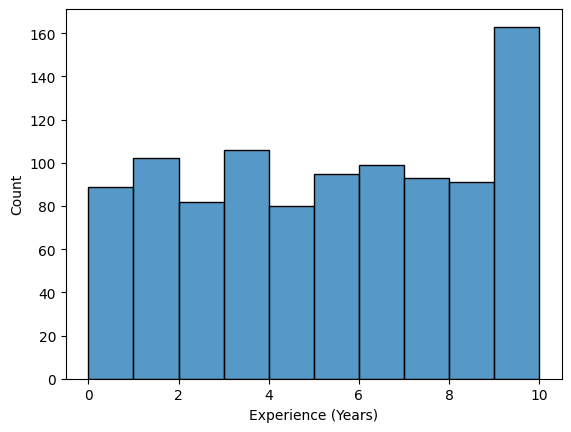

In [16]:
sns.histplot(df["Experience (Years)"], bins=10)

plt.show()

### **Salary Expectation**

Analyze salary expectations among applicants.

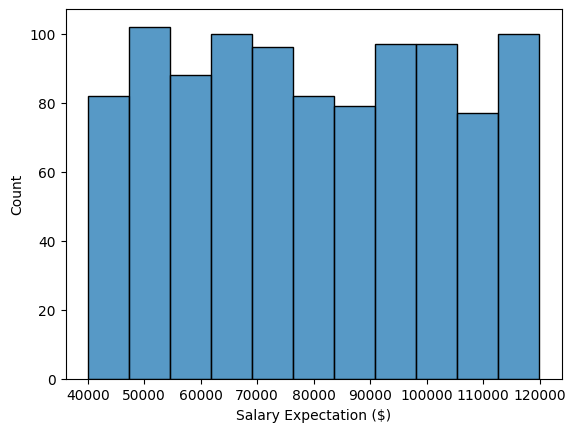

In [17]:
sns.histplot(df["Salary Expectation ($)"])

plt.show()

### **Projects Count**
Identify the spread of completed projects using a boxplot.

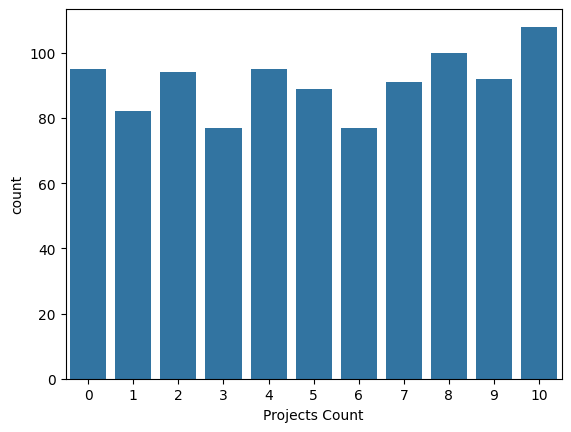

In [21]:
sns.countplot(x=df["Projects Count"])

plt.show()

## **Step 8: Encode Categorical Variables**

Machine Learning models require numerical inputs. Therefore, convert categorical columns into numerical values using Label Encoding.

In [22]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

## **Step 9: Correlation Heatmap**

Visualize the correlation among numerical variables using a heatmap.

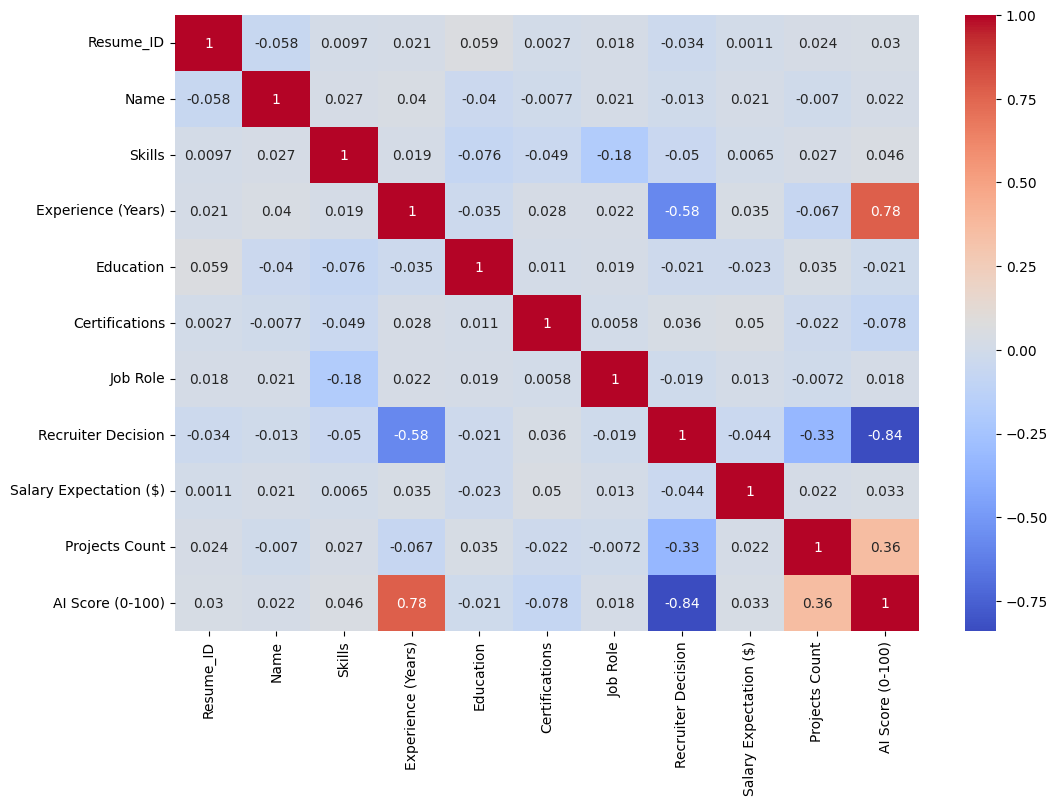

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

## **Step 10: Select Features and Target**

Separate the input features (X) from the target variable (y).

In [24]:
X = df.drop(["Recruiter Decision", "Resume_ID", "Name"], axis=1)

y = df["Recruiter Decision"]

## **Step 11: Split the Dataset**

Split the data into training and testing sets using an 80:20 ratio.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## **Step 12: Logistic Regression**

Train the Logistic Regression model and evaluate its performance.

In [27]:
lr = LogisticRegression(max_iter=100)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
accuracy_score(y_test, pred_lr)

0.92

In [29]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       154
           1       0.89      0.74      0.81        46

    accuracy                           0.92       200
   macro avg       0.91      0.86      0.88       200
weighted avg       0.92      0.92      0.92       200



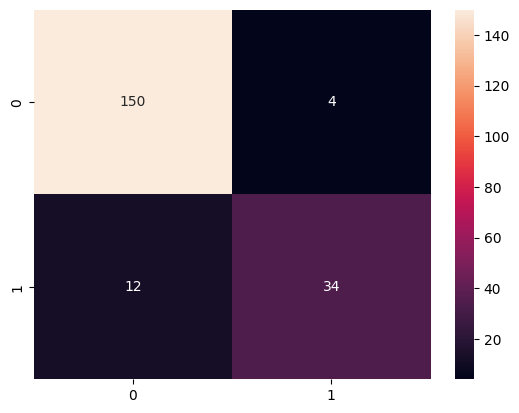

In [30]:
sns.heatmap(confusion_matrix(y_test, pred_lr),
            annot=True,
            fmt='d')

plt.show()

## **Step 13: Decision Tree Classifier**

Train a Decision Tree model for comparison.

In [31]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [32]:
accuracy_score(y_test, pred_dt)

1.0

## **Step 14: Random Forest Classifier**

Train a Random Forest model, which often performs well on structured datasets.

In [33]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [34]:
accuracy_score(y_test, pred_rf)

1.0

## **Step 15: Model Comparison**

Compare the accuracy of all trained models.

In [35]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.92
1,Decision Tree,1.00
2,Random Forest,1.00


## **Step 16: Feature Importance**

Identify which features contribute the most to hiring predictions.

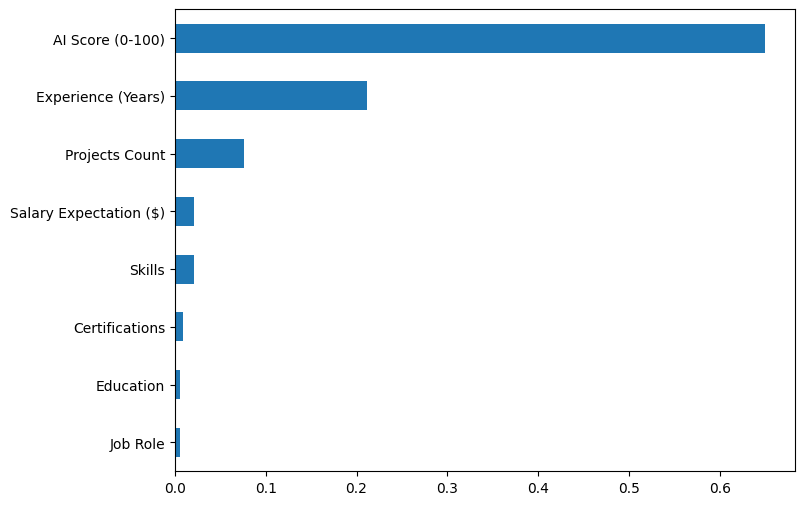

In [36]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.show()

## **Step 17: Save the Trained Model**

Store the trained Random Forest model for future predictions.

In [37]:
joblib.dump(rf, "Hiring_Model.pkl")

['Hiring_Model.pkl']

## **Step 18: Load the Saved Model**

Load the saved model whenever predictions are required.

In [38]:
model = joblib.load("Hiring_Model.pkl")

## **Step 19: Predict Hiring Decision**

Test the trained model using a new candidate's information.

In [41]:
sample = [[
    2,      # Skills
    4,      # Experience
    1,      # Education
    3,      # Certifications
    5,      # Job Role
    65000,  # Salary Expectation
    6,      # Projects Count
    75      # Resume Score
]]

In [42]:
prediction = model.predict(sample)
print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [43]:
if prediction[0] == 1:
    print("Candidate is likely to be Hired")
else:
    print("Candidate is likely to be Rejected")

Candidate is likely to be Rejected


# **Project Conclusion**

In this project, we developed an AI-Based Hiring Prediction System capable of predicting whether a candidate is likely to be hired or rejected based on resume attributes.

### ***Key Accomplishments***

- Loaded and explored the hiring dataset.
- Performed data cleaning by handling missing values and duplicates.
- Conducted Exploratory Data Analysis (EDA).
- Encoded categorical variables for machine learning.
- Trained Logistic Regression, Decision Tree, and Random Forest models.
- Compared model performance using accuracy.
- Identified important features influencing hiring decisions.
- Saved the best-performing model for future use.
- Successfully predicted hiring outcomes for new candidate data.

This project demonstrates an end-to-end Machine Learning workflow and showcases practical skills in data preprocessing, visualization, model training, evaluation, and deployment readiness.